# Tokenization

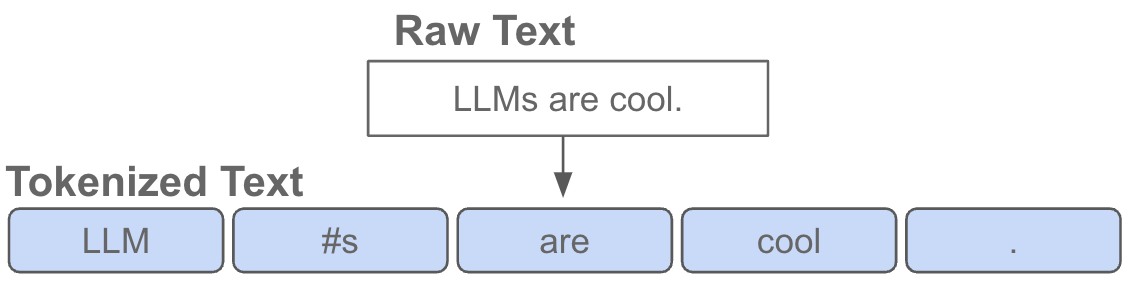

In [ ]:
import torch
from transformers import AutoTokenizer
torch.cuda.is_available()
torch.device('cuda')

device(type='cuda')

In [ ]:
# load the tokenizer
tokenizer = AutoTokenizer.from_pretrained('CohereLabs/North-Mini-Code-1.0')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/2.34k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/8.95k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/28.2M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/672 [00:00<?, ?B/s]

chat_template.jinja:   0%|          | 0.00/12.4k [00:00<?, ?B/s]

In [ ]:
# raw text
text = "This raw text will be tokenized"

In [ ]:
# create tokenize using tokenizer
tokens = tokenizer.tokenize(text)
token_id = tokenizer.encode(text) # directly create token ids

print(f"Tokens: {tokens}")
print(f"Token IDs: {token_id}")

Tokens: ['This', 'Ġraw', 'Ġtext', 'Ġwill', 'Ġbe', 'Ġtokenized']
Token IDs: [2, 1905, 10268, 1541, 642, 361, 216412]


In [ ]:
# create token embedding layer
VOCABULARY_SIZE: int = tokenizer.vocab_size
EMBEDDING_DIM: int = 768
token_embedding_layer = torch.nn.Embedding(
    num_embeddings=VOCABULARY_SIZE,
    embedding_dim=EMBEDDING_DIM
)

In [ ]:
# get token embeddings (IDs must be passed as a tensor, not a list)
print(f"Max token ID: {max(token_id)}")
print(f"Vocab size for embedding layer: {VOCABULARY_SIZE}")
token_emb = token_embedding_layer(torch.tensor(token_id, dtype=torch.long))
print(f'Token Embeddings shape: {token_emb.shape}')
print(f'Token Embeddings: {token_emb}')

Max token ID: 216412
Vocab size for embedding layer: 255000
Token Embeddings shape: torch.Size([7, 768])
Token Embeddings: tensor([[ 0.8890,  0.7130,  2.1432,  ..., -1.2103,  1.0569,  0.3759],
        [ 0.3684,  0.4674, -0.4932,  ..., -0.4351, -0.1309,  0.1823],
        [ 0.7727,  0.8325,  0.1465,  ...,  0.1795, -0.7923, -0.4852],
        ...,
        [ 0.2088,  0.3748,  0.8936,  ...,  0.1203, -1.4314,  1.7634],
        [-1.3518, -0.8441,  0.9362,  ...,  1.4752, -1.0791,  0.7012],
        [-0.3458,  0.6038, -0.8215,  ..., -0.1329, -1.5131, -0.3895]],
       grad_fn=<EmbeddingBackward0>)


# Attention Machanism

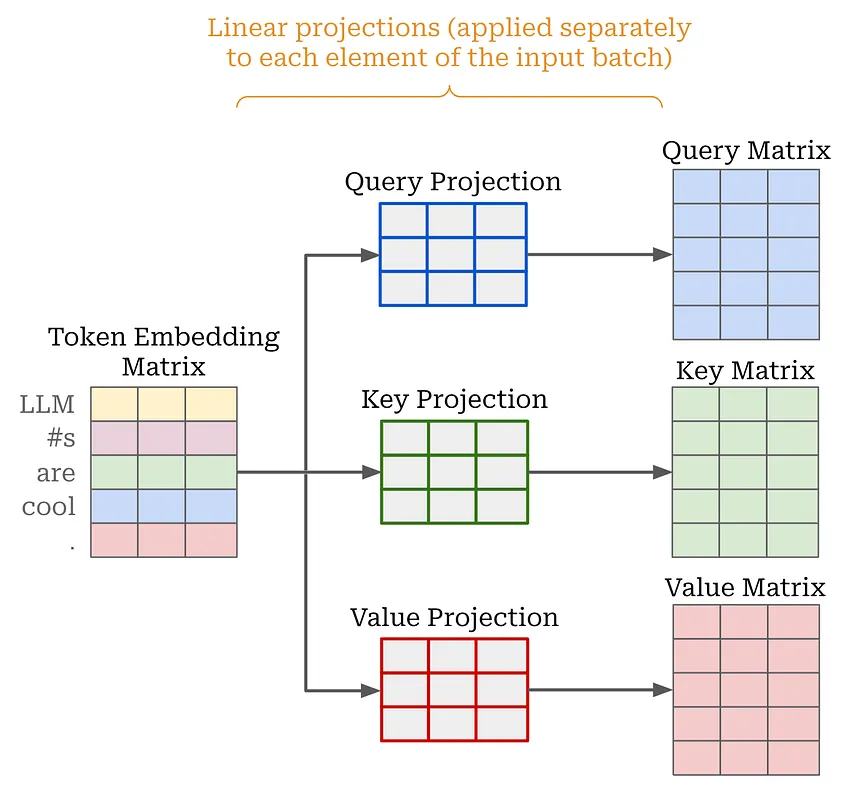

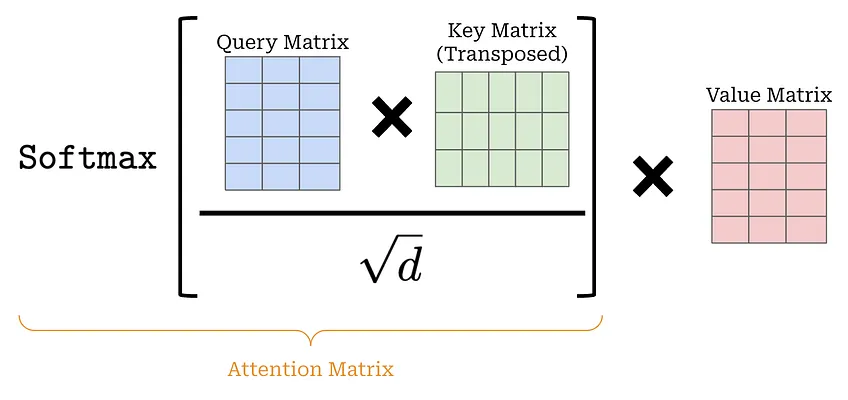

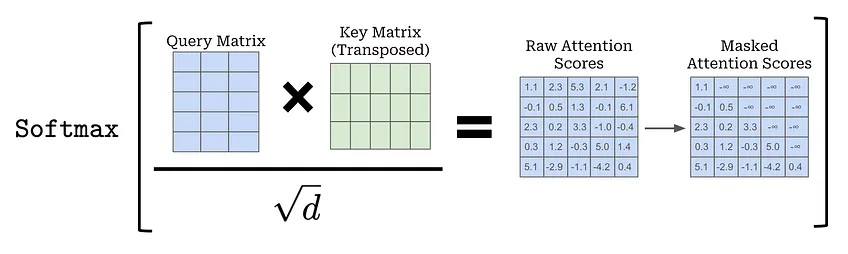

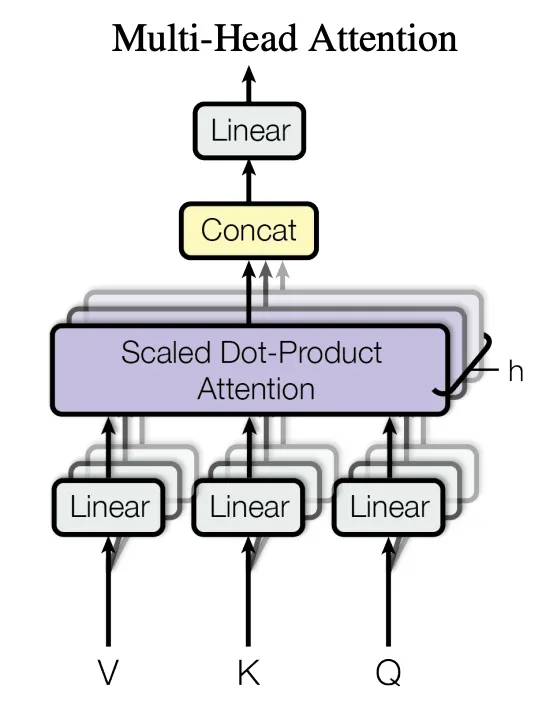

In [ ]:
import math
import torch
from torch import nn
import torch.nn.functional as F

In [ ]:
class CasualSelfAttention(nn.Module):

  def __init__(self, embedding_dim: int, num_heads: int, max_token_length: int, bias: bool=False, dropout: float=0.0):
    super().__init__()

    assert embedding_dim % num_heads == 0
    #"Embedding dimension must be divisible by the number of heads"

    # key, query, value projections for all heads, but in a batch
    # Output is 3X the dimension because it includes key, query and value
    self.c_attn = nn.Linear(embedding_dim, 3*embedding_dim, bias=bias)

    #projection of concatenated attention head outputs
    self.c_proj = nn.Linear(embedding_dim, embedding_dim, bias=bias)

    # regularization
    self.attn_dropout = nn.Dropout(dropout)
    self.resid_dropout = nn.Dropout(dropout)
    self.num_heads = num_heads
    self.embedding_dim = embedding_dim

    # causal mask to ensure that attention is only applied to
    # the left in the input sequence
    self.register_buffer("mask", torch.tril(torch.ones(max_token_length, max_token_length)))

  def forward(self, x):
    B, T, C = x.size()
    # batch size, sequence length, embedding dimensionality

    # Compute query, key, and value vectors for all heads in batch
    # split the output into separate query, key, and value tensorsd
    # [B, T, embedding_dim]
    q, k, v = self.c_attn(x).split(self.embedding_dim, dim=2)

    # reshape tensor into sequence of smaller token vectors for each head
    k = k.view(B, T, self.num_heads, self.embedding_dim // self.num_heads).transpose(1,2) # [B, T, num_head, emnedding_dim//num_head]
    q = q.view(B, T, self.num_heads, self.embedding_dim//self.num_heads).transpose(1,2) # [B, T, num_head, emnedding_dim//num_head]
    v = v.view(B, T, self.num_heads, self.embedding_dim//self.num_heads).transpose(1,2) # [B, T, num_head, emnedding_dim//num_head]

    # Compute the attention matrix, perform maskeing, and apply dropout
    att = (q @ k.transpose(-2, -1)) * (1.0 / math.sqrt(k.size(-1)))
    att = att.masked_fill(self.mask[:T, :T] == 0, float("-inf"))
    att = F.softmax(att, dim=-1)
    att = self.attn_dropout(att)

    # compute output vectors for each token
    y = att @ v # [B, num_head, T, T] x [B, num_head, T, emnedding_dim//num_head] -> [B, num_head, T, emnedding_dim//num_head]

    # Concatenate outputs from each attention head and linearly project
    y = y.transpose(1, 2).contiguous().view(B, T, self.embedding_dim) # [B, num_head, T, emnedding_dim//num_head] -> [B, T, embedding_dim]
    y = self.resid_dropout(self.c_proj(y))
    return y

# Expert Layer


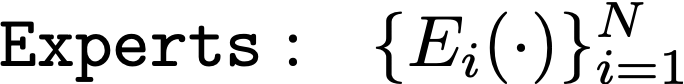

In [ ]:
import torch
from torch import nn

In [ ]:
class MLPExperts(nn.Module):

  def __init__(self, embedding_dim, num_expert, bias=False, dropout=0.2):
    super().__init__()

    self.bias = bias
    self.c_fc = nn.Parameter(torch.empty(num_expert, embedding_dim, 4*embedding_dim))
    self.c_proj = nn.Parameter(torch.empty(num_expert, 4*embedding_dim, embedding_dim))
    self.fc_bias = nn.Parameter(torch.empty(num_expert, 1, 4*embedding_dim)) if self.bias else None
    self.proj_bias = nn.Parameter(torch.empty(num_expert, 1, embedding_dim)) if self.bias else None
    self.gelu = nn.GELU()
    self.dropout = nn.Dropout(dropout)

  def forward(self, x):
    x = torch.bmm(x, self.c_fc)
    if self.bias:
      x += self.fc_bias
    x = self.gelu(x)
    x = torch.bmm(x, self.c_proj)
    if self.bias:
      x += self.proj_bias
    x = self.dropout(x)
    return x

# Routing Tokens to Experts

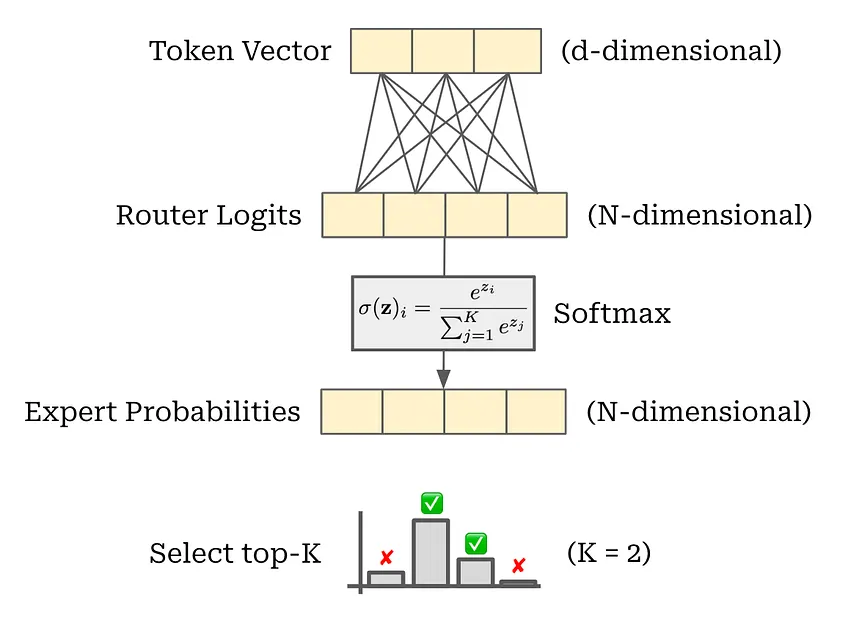

In [ ]:
import torch
from torch import nn
from torch.nn import functional as F

In [ ]:
class BasicSoftmaxRouter(nn.Module):

  def __init__(self, embedding_dim, num_expert, top_k, use_noisy_top_k=False):
    super().__init__()

    # router settings
    self.top_k = top_k
    assert self.top_k >= 1 and self.top_k <= num_expert
    self.use_noisy_top_k = use_noisy_top_k

    # linear projection for (noisy) softmax routing
    self.w_g = nn.Linear(embedding_dim, num_expert, bias=False)
    self.w_noise = nn.Linear(embedding_dim, num_expert, bias=False) if self.use_noisy_top_k else None

  def forward(self, x):

    logits = self.w_g(x)
    if self.user_noisy_top_k:
      noise = F.softplus(self.w_noise(x))
      noise *= torch.randn_like(noise)
      logits += noise
    top_k_logits, top_k_indices = logits.topk(self.top_k, dim=-1)
    return top_k_logits, top_k_indices

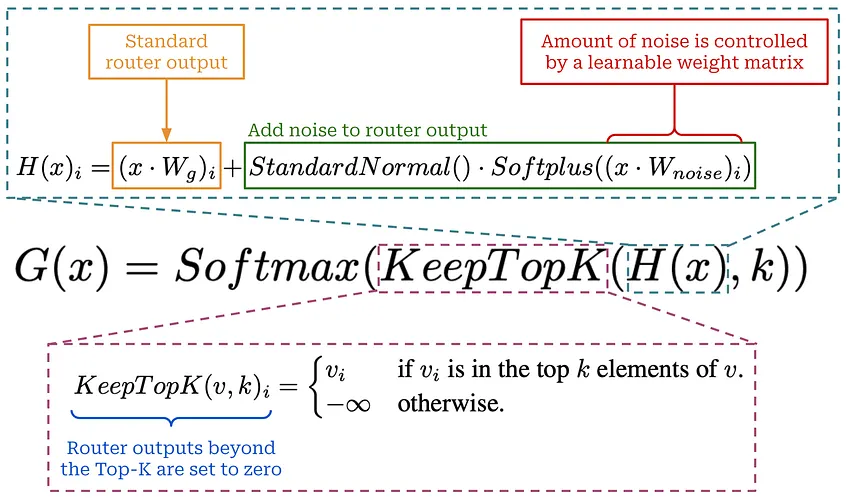

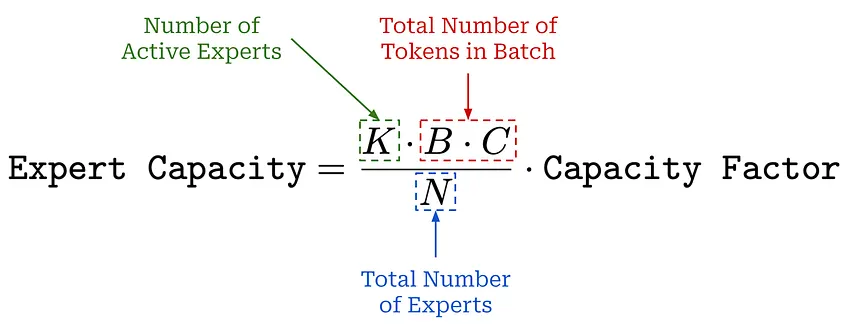

In [ ]:
import math
import torch
from torch import nn
from torch.nn import functional as F

In [ ]:
from IPython.utils.sysinfo import num_cpus
class Router(nn.Module):
  def __init__(self, embedding_dim, num_expert, top_k, user_noisy_top_k=True, capacity_factor=1.25):
    super().__init__()

    self.embedding_dim = embedding_dim
    self.num_expert = num_expert
    self.top_k = top_k
    assert self.top_k >= 1 and self.top_k <= num_expert
    self.use_noisy_top_k = user_noisy_top_k
    self.capacity_factor = capacity_factor
    self.w_g = nn.Linear(embedding_dim, num_expert, bias=False)
    self.w_noise = nn.Linear(embedding_dim, num_expert, bias=False) if self.use_noisy_top_k else None

  def forward(self, x):
    # get the total number of tokens in the batch
    B, C, _ = x.size()
    num_tokens = B * C

    logits = self.w_g(x)
    if self.use_noisy_top_k:
      #(optionally) add noise into the router
      noise = F.softplus(self.w_noise(x))
      noise *= torch.randn_like(noise)
      logits += noise

    # top-k expert selection, compute probilities over actuve experts
    top_k_logits, top_k_indices = logits.topk(self.top_k, dim=-1)
    router_probs = torch.full_like(logits, float('-inf'))
    router_probs.scatter_(-1, top_k_indices, top_k_logits)
    router_probs = F.softmax(router_probs, dim=-1)

    # compute the expert capacity
    exp_capacity = math.floor(self.top_k * self.capacity_factor * num_tokens / self.num_expert)
    exp_capacity += exp_capacity % 2 # make sure expert capacity is an even integer
    exp_capacity = int(exp_capacity)

    # make a multi-hot mask of chosen experts
    # values are 0 if expert not chosen, 1 if expert chosen
    exp_mask = F.one_hot(top_k_indices, num_classes=self.num_expert)
    exp_mask = exp_mask.view(num_tokens, self.top_k, self.num_expert)
    exp_mask = exp_mask.permute(1,0,2)

    # compute index for each token in expert batch
    # NOTE: cumsum counts top-1 first, top-2 second, etc.
    # to prioritize top experts when dropping tokens
    exp_rank = exp_mask.reshape(self.top_k * num_tokens, self.num_expert)
    exp_rank = torch.cumsum(exp_rank, dim=0)
    exp_rank = exp_rank.reshape(self.top_k, num_tokens, self.num_expert)

    # mask entries beyind expert capacity and compute used capacity
    exp_mask *= torch.lt(exp_rank, exp_capacity)

    # matrix storing tokens position in batch of corresponding expert
    exp_rank = torch.sum(exp_mask * exp_rank, dim=-1)

    # mask probabilities to only include selected experts
    router_probs = router_probs.view(num_tokens, self.num_expert)[None, :]
    exp_weights = exp_mask * router_probs

    # position of each toekn within the capacity of the selected expert
    exp_rank_sc = F.one_hot(exp_rank, num_classes = exp_capacity)

    # weight of the selected expert for each token at position the capacity of that expert
    exp_weights = torch.sum(exp_weights.unsqueeze(3) * exp_rank_sc.unsqueeze(2), dim=0)
    exp_mask = exp_weights.bool()

    # reshape token into batches for each expert, return both waights and batches
    # [num_expert, exp_capacity, B*C] * [B*C, embedding_dim] -> [num_expert, exp_capacity, n_embed]
    x = x.view(num_tokens, self.embedding_dim)
    expert_batches = exp_mask.permute(1,2,0).type_as(x) @ x
    return exp_weights, exp_mask, expert_batches

# Load Balancing and Auxilary Losses

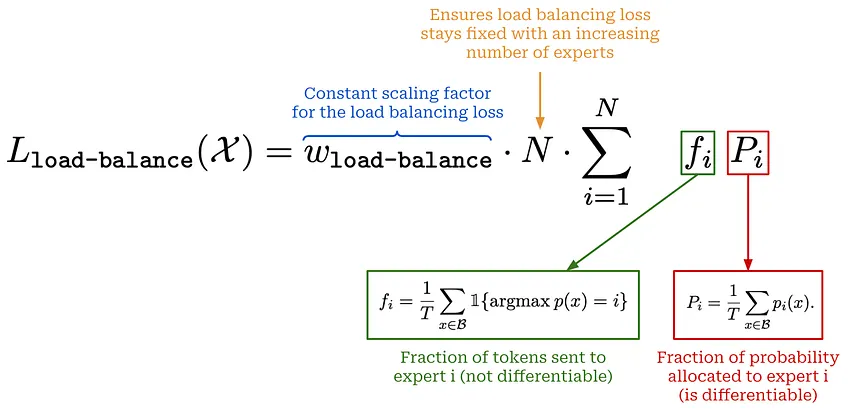

In [ ]:
import torch
import torch.nn.functional as F

Batch_size = 16
sequence_length = 256
num_expert = 8
k = 2 # number of active expert

# define trnsors needed to compute load balancing loss
# Corrected: indices should range from 0 to num_expert - 1
indices = torch.randint(0, num_expert, (Batch_size, sequence_length, k))
expert_probs = F.softmax(torch.rand(Batch_size, sequence_length, num_expert), dim=2)

with torch.no_grad():
  one_hot_indices = F.one_hot(indices, num_classes=num_expert)
  one_hot_indices = torch.sum(one_hot_indices.float(), dim=2)
  tokens_per_expert = torch.mean(one_hot_indices.float(), dim=(0,1))

prob_per_expert = torch.mean(expert_probs.float(), dim=(0,1))

load_balance_loss = num_expert * torch.sum(prob_per_expert * tokens_per_expert)

# Router Z-loss

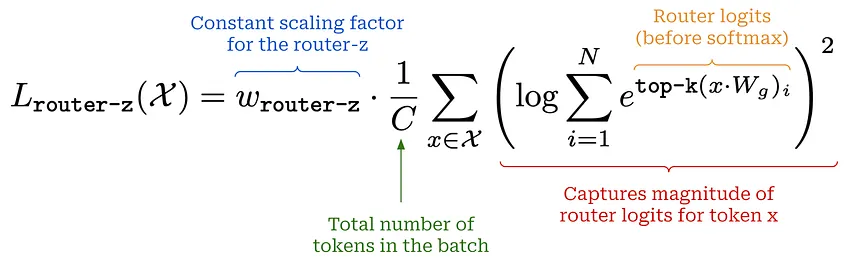

In [ ]:
router_logits = torch.rand(Batch_size, sequence_length, num_expert)

router_z_loss = torch.logsumexp(router_logits, dim=-1).mean()
print(router_z_loss)

tensor(2.6183)


# Combining Auxiliary Losses


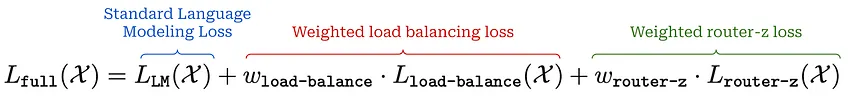

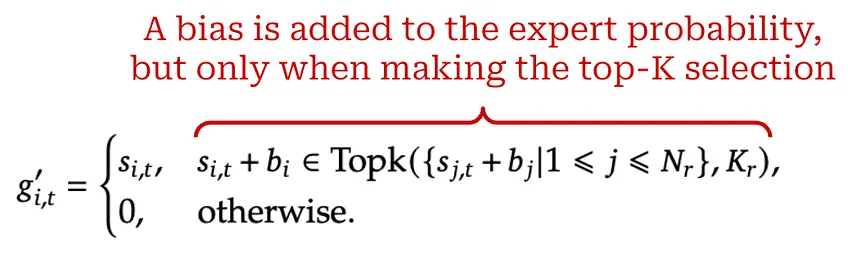

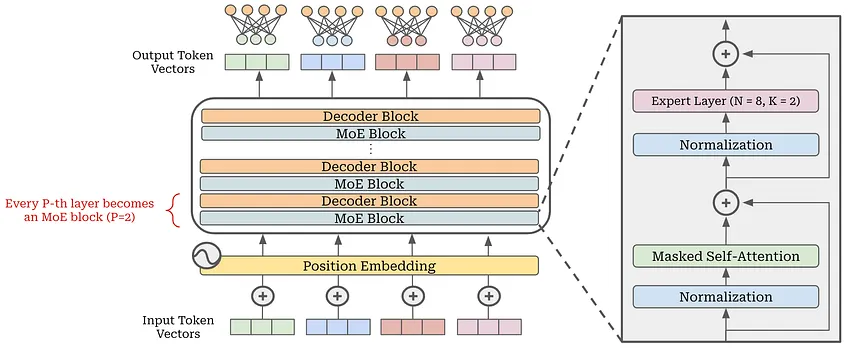

# Computing expert layer Output

In [ ]:
from torch import nn

class MOELayer(nn.Module):
  def __init__(self, embedding_dim, num_expert, top_k, use_noisy_top_k=True, capacity_factor=1.25, bias=False, dropout=0.2):
    super().__init__()

    self.router = Router(embedding_dim,
                         num_expert,
                         top_k,
                         use_noisy_top_k,
                         capacity_factor)
    self.experts = MLPExperts(embedding_dim=embedding_dim,
                              num_expert=num_expert,
                              bias=bias,
                              dropout=dropout)

  def forward(self, x: torch.Tensor):
    B, C, d = x.size() # track the original shape of input
    num_tokens = (B*C)

    # pass each token through the router
    exp_weight, exp_mask, exp_batches = self.router(x)

    # compute expert outout
    exp_out = self.experts(exp_batches)

    # aggregate expert output based on router weights
    exp_weigth = exp_weight.view(num_tokens, -1)
    exp_out = exp_out.view(-1, d)
    output = exp_weigth @ exp_out

    return output.view(B, C, d)

# Creating MOE Block


In [ ]:
from torch import nn

class MOEBlock(nn.Module):
  def __init__(self, embedding_dim, num_head, max_sequence_length, num_expert, top_k, use_noisy_top_k=True, capacity_factor=1.25, bias=False, dropout=0.2):
    super().__init__()

    self.ln_1 = nn.LayerNorm(embedding_dim)
    self.attn = CasualSelfAttention(embedding_dim=embedding_dim,
                                    num_heads=num_head,
                                    max_token_length=max_sequence_length,
                                    bias = bias,
                                    dropout = dropout)
    self.ln_2 = nn.LayerNorm(embedding_dim)
    self.moe_layer = MOELayer(embedding_dim=embedding_dim,
                              num_expert=num_expert,
                              top_k=top_k,
                              use_noisy_top_k=use_noisy_top_k,
                              capacity_factor=capacity_factor,
                              bias=bias,
                              dropout=dropout)

  def forward(self, x):
    x = x+self.attn(self.ln_1(x))
    x = x+self.moe_layer(self.ln_2(x))
    return x

In [ ]:
import torch
import torch.nn.functional as F

def compute_model_loss(logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
    """
    Computes the cross-entropy loss given model output (logits) and target labels.

    Args:
        logits (torch.Tensor): The raw logits from the model,
                               shape (batch_size, sequence_length, vocab_size).
        targets (torch.Tensor): The target token IDs,
                                shape (batch_size, sequence_length).

    Returns:
        torch.Tensor: The computed cross-entropy loss.
    """
    # Reshape logits for cross_entropy: (N, C, ...) where C is num_classes
    # Here, N = batch_size * sequence_length, C = vocab_size
    batch_size, sequence_length, vocab_size = logits.shape
    main_loss = F.cross_entropy(logits.view(-1, vocab_size), targets.view(-1))

    # In a full Mixture-of-Experts setup, you would typically add auxiliary losses
    # from the router (e.g., load_balance_loss, router_z_loss) to this main_loss.
    # For example:
    # total_loss = main_loss + aux_loss_weight * (load_balance_loss + router_z_loss)
    # However, this function solely focuses on the primary model's cross-entropy loss.

    return main_loss

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# Placeholder constants for LanguageModel initialization. Adjust as needed.
# VOCABULARY_SIZE and EMBEDDING_DIM are already defined in the notebook context.
MAX_SEQUENCE_LENGTH = 1024 # Maximum sequence length the model can handle
NUM_LAYERS = 6             # Number of MOEBlock layers in the model
NUM_HEADS = 8              # Number of attention heads in CasualSelfAttention
NUM_EXPERT = 8             # Number of experts in MOELayer
TOP_K_EXPERT = 2           # Number of top experts chosen by the router

class LanguageModel(nn.Module):
    def __init__(self,
                 vocab_size: int,
                 embedding_dim: int,
                 num_layers: int,
                 num_heads: int,
                 max_sequence_length: int,
                 num_expert: int,
                 top_k_expert: int):
        super().__init__()
        self.vocab_size = vocab_size
        self.embedding_dim = embedding_dim
        self.max_sequence_length = max_sequence_length

        self.token_embedding_table = nn.Embedding(vocab_size, embedding_dim)
        self.position_embedding_table = nn.Embedding(max_sequence_length, embedding_dim)
        self.blocks = nn.Sequential(*[
            MOEBlock(embedding_dim, num_heads, max_sequence_length, num_expert, top_k_expert)
            for _ in range(num_layers)
        ])
        self.ln_f = nn.LayerNorm(embedding_dim) # final layer norm
        self.lm_head = nn.Linear(embedding_dim, vocab_size) # language model head for logits

    def forward(self, idx: torch.Tensor, targets: torch.Tensor = None):
        B, T = idx.shape

        # Ensure input sequence length does not exceed max_sequence_length
        if T > self.max_sequence_length:
            idx = idx[:, -self.max_sequence_length:]
            T = self.max_sequence_length
            if targets is not None:
                targets = targets[:, -self.max_sequence_length:]

        # Token and position embeddings
        token_emb = self.token_embedding_table(idx) # (B, T, embedding_dim)
        pos_emb = self.position_embedding_table(torch.arange(T, device=idx.device)) # (T, embedding_dim)
        x = token_emb + pos_emb # (B, T, embedding_dim)

        # Apply transformer blocks (MOEBlocks)
        x = self.blocks(x) # (B, T, embedding_dim)

        # Final layer norm and linear layer for logits
        x = self.ln_f(x)
        logits = self.lm_head(x) # (B, T, vocab_size)

        loss = None
        if targets is not None:
            # Reshape logits for cross_entropy: (N, C) where N = B*T and C = vocab_size
            logits_reshaped = logits.view(-1, logits.shape[-1])
            targets_reshaped = targets.view(-1)
            loss = F.cross_entropy(logits_reshaped, targets_reshaped)

        return logits, loss

    @torch.no_grad()
    def generate(self, idx: torch.Tensor, max_new_tokens: int):
        # idx is (B, T) array of indices in the current context
        for _ in range(max_new_tokens):
            # Crop idx to the last max_sequence_length tokens for efficiency
            idx_cond = idx if idx.shape[1] <= self.max_sequence_length else idx[:, -self.max_sequence_length:]

            # Get the predictions (logits)
            logits, _ = self(idx_cond) # Forward pass only for prediction, no need for loss

            # Focus only on the last time step (the predicted next token)
            logits = logits[:, -1, :] # becomes (B, vocab_size)

            # Apply softmax to get probabilities
            probs = F.softmax(logits, dim=-1) # (B, vocab_size)

            # Sample from the distribution (e.g., using multinomial sampling for diversity)
            idx_next = torch.multinomial(probs, num_samples=1) # (B, 1)

            # Append sampled index to the running sequence
            idx = torch.cat((idx, idx_next), dim=1) # (B, T+1)
        return idx

def generate_next_token(model: LanguageModel, tokenizer, input_text: str, max_new_tokens: int = 1, device: str = 'cpu') -> str:
    """
    Generates the next token(s) using a given LanguageModel and tokenizer.

    Args:
        model (LanguageModel): The language model to use for generation.
        tokenizer: The tokenizer object (e.g., from Hugging Face) corresponding to the model.
        input_text (str): The input text to condition the generation on.
        max_new_tokens (int): The maximum number of new tokens to generate.
        device (str): The device to run the model on ('cpu' or 'cuda').

    Returns:
        str: The generated text, including the original input and the new token(s).
    """
    model.eval() # Set model to evaluation mode
    model.to(device)

    # Encode the input text to token IDs
    input_ids = torch.tensor(tokenizer.encode(input_text), dtype=torch.long).unsqueeze(0).to(device)

    # Generate tokens using the model's generate method
    generated_ids = model.generate(input_ids, max_new_tokens=max_new_tokens)

    # Decode the generated token IDs back to text
    # generated_ids[0] converts from (1, T_new) to (T_new) list of IDs
    generated_text = tokenizer.decode(generated_ids[0].tolist())

    return generated_text

In [ ]:
print("Initializing Language Model...")

# Set device
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# Initialize the LanguageModel with the placeholder constants
model = LanguageModel(
    vocab_size=VOCABULARY_SIZE,
    embedding_dim=EMBEDDING_DIM,
    num_layers=NUM_LAYERS,
    num_heads=NUM_HEADS,
    max_sequence_length=MAX_SEQUENCE_LENGTH,
    num_expert=NUM_EXPERT,
    top_k_expert=TOP_K_EXPERT
).to(device)

print(f"Model initialized and moved to {device}.")
print(f"Input text: '{text}'")

# --- Generate Next Token ---

print("\n--- Generating next token(s) ---")
# Generate 5 new tokens based on the input text
generated_output = generate_next_token(model, tokenizer, text, max_new_tokens=5, device=device)
print(f"Generated output (input + 5 new tokens): '{generated_output}'")

# --- Compute Logits and Loss for a sequence ---

print("\n--- Computing Logits and Loss ---")
# For computing logits and loss, we need an input sequence and a target sequence.
# Let's use the 'token_id' as input and create a dummy target by shifting it.

# Convert token_id list to a tensor and add batch dimension
input_ids = torch.tensor(token_id, dtype=torch.long).unsqueeze(0).to(device)

# Create dummy targets by shifting the input sequence (standard for language modeling)
# The target for token i is token i+1
target_ids = torch.cat((input_ids[:, 1:], torch.tensor([[tokenizer.pad_token_id or 0]], dtype=torch.long, device=device)), dim=1)

# Ensure targets have the same length as input_ids after potential cropping in forward pass
# if input_ids is longer than max_sequence_length
# In this example, token_id is short, so this won't crop, but it's good practice.
current_sequence_length = min(input_ids.shape[1], MAX_SEQUENCE_LENGTH)
input_ids_for_forward = input_ids[:, :current_sequence_length]
target_ids_for_forward = target_ids[:, :current_sequence_length]

# Perform a forward pass to get logits and loss
# Set model to train mode if you want to see effects of dropout/etc., otherwise eval mode is fine
model.train() # Or model.eval() if only interested in logits for inference

logits, loss = model(input_ids_for_forward, target_ids_for_forward)

print(f"Input sequence length: {input_ids_for_forward.shape[1]}")
print(f"Logits shape: {logits.shape}") # (batch_size, sequence_length, vocab_size)
print(f"Computed Loss: {loss.item():.4f}")

print("\nExample of logit values (first token, first 5 vocab entries):\n", logits[0, 0, :5].detach().cpu().numpy())

# The compute_model_loss function can also be used directly on logits and targets
manual_loss = compute_model_loss(logits, target_ids_for_forward)
print(f"Loss computed manually using compute_model_loss function: {manual_loss.item():.4f}")

Initializing Language Model...
Model initialized and moved to cuda.
Input text: 'This raw text will be tokenized'

--- Generating next token(s) ---
Generated output (input + 5 new tokens): '<BOS_TOKEN>This raw text will be tokenized.activ příliš attacker सदस्यों.Encoding'

--- Computing Logits and Loss ---
Input sequence length: 7
Logits shape: torch.Size([1, 7, 255000])
Computed Loss: 12.6506

Example of logit values (first token, first 5 vocab entries):
 [ 0.4287466  -0.39346954 -0.39415422  0.53812397 -0.16012809]
Loss computed manually using compute_model_loss function: 12.6506
